In [161]:
from dolfin import *
import numpy as np
import matplotlib.pyplot as plt
from fenics import project
import torch
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
import os
import argparse
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import imageio
from beam_fea_solver import compute_von_mises_3d
from pathlib import Path
from dataclasses import dataclass, asdict

In [ ]:
@dataclass
class Stats:
    mean: torch.Tensor
    std: torch.Tensor

In [174]:
dt = 0.08

In [175]:
from pathlib import Path

data_dir = Path("Results/train/graphs")
filenames = list(data_dir.glob("*.pt"))

train_graphs = []
categorical_node_features = []
valued_node_features = []
edge_features = []
targets = []
for idx, filename in enumerate(filenames):
    dataloader = torch.load(filename, weights_only=False)
    for data in dataloader:
        graph = data.to("cpu")
        graphs.append(graph)
    for graph in graphs:
        boundary_condition = graph.x_bc  # 1 fixed, 0 free
        node_force = graph.x_node_force  # external force on node
        x = graph.x

        categorical_node_features.append(boundary_condition)
        valued_node_features.append(torch.concat([x, graph.x_vel_t, node_force], dim=1))
        train_graphs.append(Data(edge_index=graph.edge_index))

        src, dst = graph.edge_index
        xij = x[dst] - x[src]
        xij_norm = torch.norm(xij, dim=1).unsqueeze(1)
        edge_features.append(torch.concat([xij, xij_norm], dim=1))

        von_mises = compute_von_mises_3d(graph.y_sig_t).unsqueeze(1)
        targets.append(torch.concat([graph.y_acc_t, von_mises], dim=1))


def compute_stats(tensor_list) -> Stats:
    # would also be an option to batch over all tensors
    # Batch.from_data_list(train_graphs).x.mean(dim=0)
    # but this uses less memory

    sum = 0
    sum_sq = 0
    count = 0
    for tensor in tensor_list:
        sum += tensor.sum(dim=0)
        sum_sq += (tensor**2).sum(dim=0)
        count += tensor.shape[0]
    mean = sum / count
    var = (sum_sq / count) - (mean**2)
    std = torch.sqrt(var)
    return Stats(mean=mean, std=std)


def normalize(tensor: torch.Tensor, stats: Stats, eps: float = 1e-8) -> torch.Tensor:
    return (tensor - stats.mean) / (stats.std + eps)


def denormalize(tensor: torch.Tensor, stats: Stats, eps: float = 1e-8) -> torch.Tensor:
    return tensor * (stats.std + eps) + stats.mean


node_stats = compute_stats(valued_node_features)
edge_stats = compute_stats(edge_features)
target_stats = compute_stats(targets)

stats = {
    "node": asdict(node_stats),
    "edge": asdict(edge_stats),
    "target": asdict(target_stats),
}
print(stats)

for i in range(len(train_graphs)):
    _valued_node_features = normalize(valued_node_features[i], node_stats)
    _edge_features = normalize(edge_features[i], edge_stats)
    _targets = normalize(targets[i], target_stats)
    train_graphs[i].x = torch.concat(
        [categorical_node_features[i], _valued_node_features], dim=1
    )
    train_graphs[i].edge_attr = _edge_features
    train_graphs[i].y = _targets

{'node': {'mean': tensor([ 5.6398e-01,  6.2386e-02,  2.7890e-02,  1.6197e-05,  2.6936e-02,
        -4.5063e-04,  0.0000e+00,  1.1443e-02,  0.0000e+00]), 'std': tensor([0.4983, 0.1251, 0.0296, 0.0341, 0.4679, 0.0443, 0.0000, 0.1116, 0.0000])}, 'edge': {'mean': tensor([ 1.8892e-11, -1.6603e-11,  1.5711e-11,  7.2351e-02]), 'std': tensor([0.1439, 0.0254, 0.0123, 0.1275])}, 'target': {'mean': tensor([-6.9054e-06,  1.8023e-03, -5.2576e-03,  8.4858e+00]), 'std': tensor([ 0.1788,  2.0332,  0.1718, 12.3043])}}


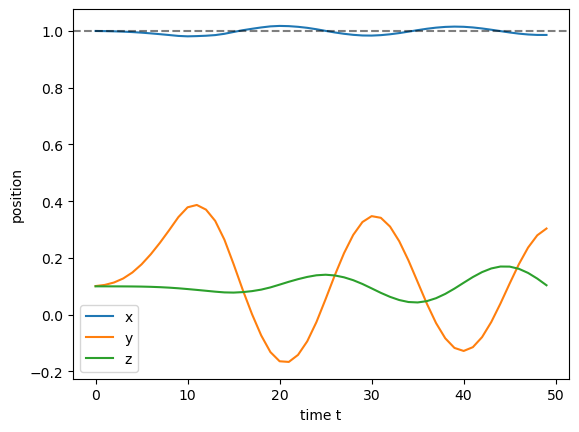

In [98]:
traj = []
for graph in graphs:
    traj.append(graph.x[-1])
traj = torch.stack(traj).numpy()
plt.plot(traj[:, 0], label="x")
plt.plot(traj[:, 1], label="y")
plt.plot(traj[:, 2], label="z")
plt.axhline(1, color="k", alpha=0.5, linestyle="--")
plt.legend()
plt.xlabel("time t")
plt.ylabel("position")
plt.show()


In [ ]:
default_params = {
    "L": 1.0,
    "W": 0.1,
    "D": 0.1,
    "NL": 4,
    "NW": 2,
    "ND": 2,
    "E": 1000.0,
    "nu": 0.3,
    "rho": 1.0,
    "eta_m": 0.01,
    "eta_k": 0.01,
    "alpha_m": 0.0,
    "alpha_f": 0.0,
    "total_time": 4.0,
    "cutoff_time_factor": 0.2,
    "num_steps": 50,
}

forces = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
cutoff_time_factors = [0.1, 0.2, 0.3]
lengths = [0.5, 0.75, 1.0]
widths = [0.05, 0.1]
depths = [0.05, 0.1]
from itertools import product

param_combinations = list(product(forces, lengths, widths))
for idx, (initial_force, L, W) in enumerate(param_combinations):
    print(f"\n=== Simulation Set {idx + 1} ===")
    params = default_params.copy()
    params.update(
        {
            "initial_force": initial_force,
            "L": L,
            "W": W,
            "mode": "train",
        }
    )
    print((initial_force, L, W))



=== Simulation Set 1 ===
(0.25, 0.5, 0.05)

=== Simulation Set 2 ===
(0.25, 0.5, 0.1)

=== Simulation Set 3 ===
(0.25, 0.75, 0.05)

=== Simulation Set 4 ===
(0.25, 0.75, 0.1)

=== Simulation Set 5 ===
(0.25, 1.0, 0.05)

=== Simulation Set 6 ===
(0.25, 1.0, 0.1)

=== Simulation Set 7 ===
(0.5, 0.5, 0.05)

=== Simulation Set 8 ===
(0.5, 0.5, 0.1)

=== Simulation Set 9 ===
(0.5, 0.75, 0.05)

=== Simulation Set 10 ===
(0.5, 0.75, 0.1)

=== Simulation Set 11 ===
(0.5, 1.0, 0.05)

=== Simulation Set 12 ===
(0.5, 1.0, 0.1)

=== Simulation Set 13 ===
(0.75, 0.5, 0.05)

=== Simulation Set 14 ===
(0.75, 0.5, 0.1)

=== Simulation Set 15 ===
(0.75, 0.75, 0.05)

=== Simulation Set 16 ===
(0.75, 0.75, 0.1)

=== Simulation Set 17 ===
(0.75, 1.0, 0.05)

=== Simulation Set 18 ===
(0.75, 1.0, 0.1)

=== Simulation Set 19 ===
(1.0, 0.5, 0.05)

=== Simulation Set 20 ===
(1.0, 0.5, 0.1)

=== Simulation Set 21 ===
(1.0, 0.75, 0.05)

=== Simulation Set 22 ===
(1.0, 0.75, 0.1)

=== Simulation Set 23 ===
(1.0,